In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading data
df = pd.read_csv("dataset.csv")
df.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [3]:
df_subset = df.sample(n = 1000, random_state=42)
df_subset.head()

,email,label
1801,use perl daily headline mailer this week on pe...,0
1190,hi red hat NUMBER NUMBER is released tomorrow ...,0
1817,forwarded by rob windsor windsor warthog com ...,0
251,quoting kevin lyda kevin dated NUMBER eNUMBER ...,0
2505,a powerhouse gifting program you don t want to...,1


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize the email text to create features
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df_subset['email'])
y = df_subset['label']


In [19]:
# train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
#train using logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
# Predicting Test
y_pred = model.predict(X_test)

In [26]:
#classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       166
           1       1.00      0.50      0.67        34

    accuracy                           0.92       200
   macro avg       0.95      0.75      0.81       200
weighted avg       0.92      0.92      0.90       200



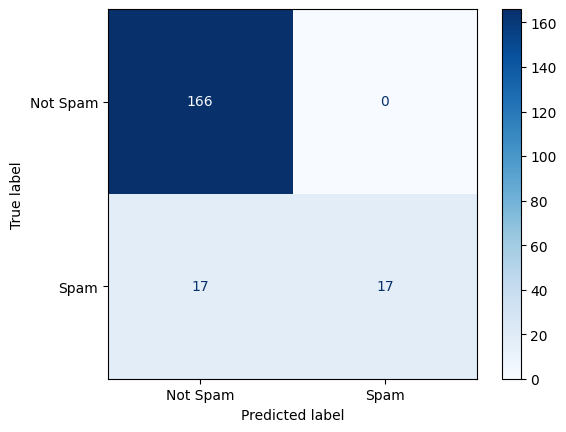

In [31]:
#confusion matrix + visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Spam", "Spam"])
disp.plot(cmap='Blues')

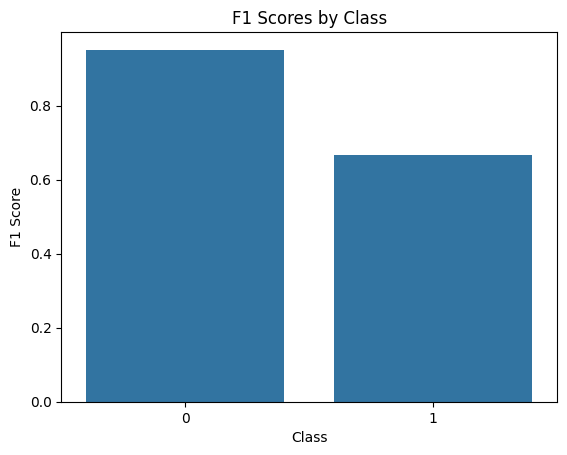

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

report_dict = classification_report(y_test, y_pred, output_dict=True)
metrics_df = pd.DataFrame(report_dict).transpose().drop(index=['accuracy', 'macro avg', 'weighted avg'])

sns.barplot(data=metrics_df[['precision', 'recall', 'f1-score']].reset_index(), x='index', y='f1-score')
plt.title("F1 Scores by Class")
plt.ylabel("F1 Score")
plt.xlabel("Class")
plt.show()
